In [1]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.impute import SimpleImputer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from joblib import dump
import warnings

# Load Data

In [2]:
data = pd.read_csv('./coc_data.csv')

## Features

### Feature Selection Strategy

Feature selection was performed in multiple, deliberately designed steps to ensure both statistical validity and clinical relevance:

**1. Exploratory Data Analysis within Cross-Validation** \
   An initial set of candidate features was identified using exploratory data analysis (EDA).
This analysis was performed only on the training data within each outer cross-validation fold to avoid data leakage and overly optimistic performance estimates.

**2. Extension with Registry-Based Features** \
   The preliminary feature set was then extended with additional variables derived from the Geriatric Trauma Register.
These features were included based on their documented relevance in geriatric trauma care, even if they were not strongly highlighted in the initial EDA.

**3. Expert-Guided Final Selection** \
The final feature subset was determined through an interdisciplinary expert review involving:
- geriatricians,
- ethics researchers, and
- IT specialists.
  
Features were selected or excluded based on:
- clinical plausibility,
- model explainability,
- ethical considerations, and
- practical availability in real-world clinical settings.

This multi-step approach balances data-driven insights with domain expertise, ensuring that the final model is both methodologically sound and clinically meaningful.

In [3]:
mode = [
    'Geschlecht (m/w)', # Sex (m/w); m=1, w=0
    'Zu Hause mit Hilfe (Ja/Nein)', # Lives at home with help (Yes/No)
    'Pflegeheim (Ja/Nein)', # Nursing home (Yes/No)
    'Betreutes Wohnen (Ja/Nein)', # Assisted Living (Yes/No)
    'Zu Hause ohne Hilfe (Ja/Nein)', # Lives at home without help (Yes/No)
    'Bekommt im Alltag Hilfe (Ja/Nein)', # needs help in ADL (Yes/No)
    'Demenz (Ja/Nein)', # Dementia (Yes/No)
    'Transfusion (Ja/Nein)', # Transfusion (Yes/No)
]

median = [
    'Anzahl an Sozialkontakten (ordinal)', #Number of social contacts (ordinal)
    'Barthel-Index vor Aufnahme (Score, ordinal)', # Barthel Index before admission (Score, ordinal)
    'Barthel-Index bei Aufnahme (Score, ordinal)', # Barthel Index at admission (Score, ordinal)
    'Barthel-Index am post-OP Tag 1 (Score, ordinal)', # Barthel Index on post-OP day 1 (Score, ordinal)
    'Barthel Index am post-OP Tag 3 (Score, ordinal)', # Barthel Index on post-OP day 3 (Score, ordinal)
    'Barthel Index Subscore 2 (Aufsetzen und Umsetzen) am post-OP Tag 3 (Score, ordinal)', # Barthel Index Subscore 2 (Sitting and Transferring) on post-OP day 3 (Score, ordinal)
    'CHARMI vor Aufnahme (Score, ordinal)', # CHARMI before illness (Score, ordinal)
    'CHARMI am post-OP Tag 1 (Score, ordinal)', # CHARMI on post-OP day 1 (Score, ordinal)
    'CHARMI am post-OP Tag 3 (Score, ordinal)', # CHARMI on post-OP day 3 (Score, ordinal)
    'ISAR (Score, ordinal)', # ISAR (Score, ordinal)
    'Clinical Frailty Scale (Score, ordinal)', # Clinical Frailty Scale (Score, ordinal)
    'ASA (Score, ordinal)', # ASA (Score, ordinal)
    'Modifizierter Charlson Comorbidity Index (Score, ordinal)', # Modified Charlson Comorbidity Index (Score, ordinal)
    'Anzahl der Dauermedikamente (n)', # Number of long-term medications (n)
    'MOCA 5min (Score, ordinal)', # MOCA 5min (Score, ordinal)
    'Pflegegrad (Score, ordinal)', # Level of care (Score, ordinal)
]

mean = [
    'Alter bei OP (Jahre)', # Age at surgery (years)
    'OP Dauer (Minuten)', # Cut-to-suture time (minutes)
    'Liegedauer auf Intensivstation (Minuten)', # Length of stay in the ICU (minutes)
]

drop_list = [
    'Quelle', # Data Source (Observational Data from SURGE-Ahead (SA), or Trauma Register (ATZ)
    'Entlassungdestination (Kategorie)', # Discharge destination (category)
    'Kreuz-Validierung (Fold)', # Cross-Validation (CV; folds). In order to prevent information spillover, folds used in EDA are kept for CV.
]

data_type_tuple = (mode, median, mean)

## Separate Data Sources
### SURGE-Ahead (SA) and Geriatric Trauma Register (ATZ)

Two independent data sources were used: **SURGE-Ahead (SA)** and the **Geriatric Trauma Register (ATZ)**.
To ensure a valid performance evaluation, these datasets were handled differently during model development.
- **SURGE-Ahead (SA)** data was used within a **nested cross-validation** framework.
The outer cross-validation loop consisted of **5 folds**, where:
    - **4 folds** were used for model training and hyperparameter optimization, and
    - **1 fold** was held out exclusively for model evaluation.
- **Trauma Register (ATZ)** data was **never used for evaluation**.
Instead, it was optionally added to the training data **only within the training folds** of the outer cross-validation loop.
- The inclusion of ATZ data was treated as a **hyperparameter**, allowing the model selection process to determine whether adding registry data improves performance.

This design ensures that model evaluation is based solely on unseen SA data, while still allowing systematic assessment of whether external registry data can enhance model training.

In [4]:
X_SA = data.loc[data['Quelle'] == 'SA'].drop(drop_list[:2], axis=1) # Keep fold information in data.
X_ATZ = data.loc[data['Quelle'] == 'ATZ'].drop(drop_list, axis=1) # The data is used as additional training data within folds.
y_SA = data.loc[data['Quelle'] == 'SA', 'Entlassungdestination (Kategorie)'].values # save as numpy array
y_ATZ = data.loc[data['Quelle'] == 'ATZ', 'Entlassungdestination (Kategorie)'].values # save as numpy array

# Training

## Functions

In [5]:
def make_train_test(X_SA, X_ATZ, y_SA, y_ATZ, fold, additional_data):
    
    """
    Performs a train-test split based on cross-validation folds, with optional inclusion of additional data.

    This function divides the primary SURGE-Ahead data (`X_SA`, `y_SA`) into training and testing sets according to the cross-validation fold indicated in the 'Kreuz-Validierung (Fold)' column of `X_SA`. 
    One fold is used for testing, while the remaining folds constitute the training set. Optionally, data from a trauma register (`X_ATZ`, `y_ATZ`) can be appended to the training data.

    Args:
        X_SA (pd.DataFrame): Primary dataset with features, including a 'Kreuz-Validierung (Fold)' column for cross-validation.
        X_ATZ (pd.DataFrame): Additional dataset to potentially augment the training data.
        y_SA (pd.Series): Target variable for the primary dataset.
        y_ATZ (np.ndarray): Target variable for the additional dataset.
        fold (int): The current cross-validation fold to use as the test set.
        additional_data (bool):  Flag indicating whether to include the additional trauma register data in the training set.

    Returns:
        tuple:  A tuple containing the training features (X_train), testing features (X_test), training target (y_train), and testing target (y_test).
    """
    
    test_index = X_SA[X_SA['Kreuz-Validierung (Fold)'] == fold].index
    train_index = X_SA[X_SA['Kreuz-Validierung (Fold)'] != fold].index
    X_temp = X_SA.drop(['Kreuz-Validierung (Fold)'], axis=1)
    X_train_temp, X_test = X_temp.iloc[train_index], X_temp.iloc[test_index]
    y_train_temp, y_test = y_SA[train_index], y_SA[test_index]
    
    if additional_data: # if trauma register data should be incorporated into the training data
        X_train = pd.concat((X_train_temp, X_ATZ))
        y_train = np.concatenate((y_train_temp, y_ATZ)) 
    else:
        X_train = X_train_temp
        y_train = y_train_temp
        
    return X_train, X_test, y_train, y_test # Classic train test split.


def make_imputation(X_train, X_test, data_type_tuple=data_type_tuple):
    
    """
    Imputes missing values in the training and testing datasets using different strategies based on data type.

    This function addresses missing data in the training and testing sets by applying different imputation methods depending on the data type of the column. 
    It uses the 'most frequent' strategy for categorical features, the 'median' strategy for ordinal features, and the 'mean' strategy for continous features.

    Args:
        X_train (pd.DataFrame): Training dataset with potential missing values.
        X_test (pd.DataFrame): Testing dataset with potential missing values.
        data_type_tuple (tuple): A tuple containing three lists of column names: 
                                  the first list corresponds to columns to be imputed with the 'most frequent' strategy, 
                                  the second with the 'median', and the third with the 'mean'.

    Returns:
        tuple: A tuple containing the imputed training features (X_train) and testing features (X_test).
    """
    
    mode, median, mean = data_type_tuple # global variable
    
    imp_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    imp_mode.fit(X_train[mode])
    X_train[mode] = imp_mode.transform(X_train[mode])
    X_test[mode] = imp_mode.transform(X_test[mode])

    imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
    imp_median.fit(X_train[median])
    X_train[median] = imp_median.transform(X_train[median])
    X_test[median] = imp_median.transform(X_test[median])
    
    imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
    imp_mean.fit(X_train[mean])
    X_train[mean] = imp_mean.transform(X_train[mean])
    X_test[mean] = imp_mean.transform(X_test[mean])

    return X_train, X_test


def train_model(X_train, y_train, params):

    """
    Trains an AdaBoost classifier with OneVsOne strategy and calibration (see Fernandez et al. 2013).

    This function trains an AdaBoostClassifier using the specified parameters and a OneVsOne strategy for multi-class classification. 
    The model is then calibrated using CalibratedClassifierCV to improve the reliability of predicted probabilities. 
    Stratified K-Fold cross-validation is employed during the calibration process.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target variable.
        params (tuple): Tuple containing parameters for the AdaBoostClassifier: 
                          (additional_data, n_estimators, learning_rate, n_splits). The first element is ignored.

    Returns:
        CalibratedClassifierCV: The trained and calibrated AdaBoost classifier.
    """

    _, n_estimators, learning_rate, n_splits = params

    # AdaBoost yields great performance in imbalanced multi-class problems (Fernandez et al. 2013)
    ada = AdaBoostClassifier(
        algorithm='SAMME',
        random_state=42,
        n_estimators=n_estimators,
        learning_rate=learning_rate
    )

    # OvO improves performance in imbalanced multi-class problems (Fernandez et al. 2013)
    ovo = OneVsOneClassifier(ada)

    # Stratified K Fold for calibration
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_splits = [(train_idx, test_idx) for train_idx, test_idx in skf.split(X_train, y_train)]

    # Sigmoid Calibration due to low sample size
    calibrator = CalibratedClassifierCV(
        estimator=ovo,
        method='sigmoid',
        cv=cv_splits,
        n_jobs=-1,
        ensemble=False
    )

    calibrator.fit(X_train, y_train)

    return calibrator


## Training

### Hyperparameter Grid

The following hyperparameters were evaluated during model selection. Their ranges and constraints were chosen to balance predictive performance, robustness, calibration quality, and model interpretability.

- `additional_data` \
A binary hyperparameter indicating whether data from the Trauma Register (ATZ) is included in the training data.
This allows systematic evaluation of whether incorporating external registry data improves model performance.

- `n_estimators` \
The number of boosting estimators used by the model.
This value was limited to a maximum of **20 estimators** to promote model robustness and maintain interpretability, avoiding overly complex ensembles.

- `learning_rate` \
The learning rate controlling the contribution of each boosting estimator.
Values were restricted to the range **0.5 to 1.0**, where:
    - the lower bound prevents the need for a large number of estimators, and
    - the upper bound reduces the risk of overfitting.  <br><br>

- `n_splits` \
The number of splits used for probability calibration.
This parameter reflects a trade-off between:
    -** fewer split**s, which may improve calibration stability, and
    -** more split**s, which increase the amount of data available for model training <br>
.

In [6]:
best_accuracy = 0
best_params = []

grid = {
    'additional_data': (False, True),
    'n_estimators': np.arange(1, 21, 1),
    'learning_rate': np.round(np.arange(0.5, 1.01, 0.1),2),
    'n_splits': np.arange(2, 6, 1).astype(int),
}

In [7]:
for additional_data in grid['additional_data']: # Hyperparameter 1

    for n_estimators in grid['n_estimators']: # Hyperparameter 2
    
        for learning_rate in grid['learning_rate']: # Hyperparamter 3
        
            for n_splits in grid['n_splits']: # Hyperparamter 4

                # hyperparameters of the current iteration
                params = (additional_data, n_estimators, learning_rate, n_splits)

                cv_X = []
                cv_y_pred = []
                cv_y_proba = []
                cv_y_test = []
        
                for fold in range(1, 6): # for each fold in the outer loop

                    X_train, X_test, y_train, y_test = make_train_test(X_SA, X_ATZ, y_SA, y_ATZ, fold=fold, additional_data=additional_data)
                    X_train, X_test = make_imputation(X_train, X_test)
                    
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore") # Minority classes may raise warnings during calibration
                        calibrator = train_model(X_train, y_train, params)
                    
                    sigmoid_proba = calibrator.predict_proba(X_test)
                    sigmoid_pred = np.argmax(sigmoid_proba, axis=1)

                    cv_X.append(X_test)
                    cv_y_pred.append(sigmoid_pred)
                    cv_y_proba.append(sigmoid_proba)
                    cv_y_test.append(y_test)

                y_proba, y_pred, y_true = np.concatenate(cv_y_proba), np.concatenate(cv_y_pred), np.concatenate(cv_y_test)
                accuracy = accuracy_score(y_true, y_pred)
                coc_X = pd.concat(cv_X, ignore_index=True)

                # Save best result
                if accuracy > best_accuracy:

                    # Print if additional trauma register data was used, for comparison (also see Golchian et al. 2026)
                    if additional_data:
                        print('With trauma register data:', accuracy)
                    else:
                        print('Without trauma register data:', accuracy)

                    best_X = coc_X.copy()
                    best_y_pred = y_pred.copy()
                    best_y_proba = y_proba.copy()
                    best_accuracy = accuracy
                    best_params = params

# Print best hyperparameters
for key, param in zip(grid.keys(), best_params):
    print(key, ':', param)

# For further analyses (other Notebooks)
best_X['coc_pred'] = best_y_pred
num_classes = best_y_proba.shape[1]
class_cols = [f'coc_proba_class{i}' for i in range(num_classes)]
best_X[class_cols] = best_y_proba
best_X.to_csv('./coc.csv', index=False)

Without trauma register data: 0.7396449704142012
Without trauma register data: 0.7455621301775148
Without trauma register data: 0.7928994082840237
Without trauma register data: 0.7988165680473372
Without trauma register data: 0.8047337278106509
With trauma register data: 0.8106508875739645
With trauma register data: 0.8165680473372781
additional_data : True
n_estimators : 12
learning_rate : 1.0
n_splits : 3


# Results

## Functions

In [8]:
def stratified_bootstrap(y, y_pred, metric, n_iterations=1000, random_state=42, **kwargs):

    """
    Performs stratified bootstrap resampling to estimate confidence intervals for a given metric.

    This function generates bootstrap samples by resampling *within* each class to maintain class proportions.
    It then calculates the specified metric on each bootstrap sample and uses the percentiles of the resulting distribution
    to estimate the confidence interval.

    Args:
        y (array-like): True target values.
        y_pred (array-like): Predicted target values.
        metric (callable): The metric function to evaluate. It should accept `y` and `y_pred` as input and return a scalar value.
        n_iterations (int): The number of bootstrap iterations to perform. Defaults to 1000.
        random_state (int): The random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments to pass to the metric function.

    Returns:
        tuple: A tuple containing the lower and upper bounds of the 95% confidence interval.
    """
    
    rng = np.random.RandomState(random_state) # Set random state for reproducibility
    y = np.array(y)
    y_pred = np.array(y_pred)
    classes = np.unique(y)
    results = []

    for _ in range(n_iterations):
        indices = []

        # Stratified bootstrap: resample WITHIN each class
        for cls in classes:
            cls_indices = np.where(y == cls)[0]
            if len(cls_indices) == 0:
                continue
            sampled = rng.choice(cls_indices, size=len(cls_indices), replace=True)
            indices.extend(sampled)

        indices = np.array(indices)
        sample_y = y[indices]
        sample_pred = y_pred[indices]

        res = metric(sample_y, sample_pred, **kwargs)
        results.append(res)

    ci_lower = np.percentile(results, 2.5)
    ci_upper = np.percentile(results, 97.5)
    
    return ci_lower, ci_upper


def select_top_rows(y_proba, data_array, percentile):
    
    """
    Selects rows from a data array based on a probability threshold.

    This function identifies and returns rows from a data array corresponding to samples with high predicted probabilities.
    It calculates a threshold based on the specified percentile of the maximum predicted probabilities for each sample and
    then selects the rows where the maximum predicted probability exceeds this threshold.

    Args:
        y_proba (np.ndarray): Predicted probabilities for each sample (shape: (n_samples, n_classes)).
        data_array (np.ndarray): The data array from which to select rows.
        percentile (float): The percentile to use for calculating the probability threshold.

    Returns:
        np.ndarray: A subset of the data array containing only the rows with high predicted probabilities.
    """
    
    threshold = np.percentile(np.max(y_proba, axis=1), percentile)
    indices = np.where(np.max(y_proba, axis=1) >= threshold)[0]
    
    return data_array[indices]
    

def calculate_top_accuracy(y_test, y_pred, y_proba, threshold=15):

    """
    Calculates the accuracy of predictions on a subset of samples with the highest predicted probabilities.

    This function selects a subset of samples based on their predicted probabilities using the `select_top_rows` function
    and then calculates the accuracy of the predictions on this subset.

    Args:
        y_test (array-like): True target values for the test set.
        y_pred (array-like): Predicted target values for the test set.
        y_proba (np.ndarray): Predicted probabilities for each sample (shape: (n_samples, n_classes)).
        threshold (float): The percentile threshold to use for selecting the top samples. Defaults to 15.

    Returns:
        float: The accuracy of the predictions on the selected top samples.
    """
    
    top_y_test = select_top_rows(y_proba, y_test, threshold)
    top_y_pred = select_top_rows(y_proba, y_pred, threshold)
    accuracy = accuracy_score(top_y_test, top_y_pred)

    return accuracy
    

def auc_with_ci_stratified(y_true_bin, y_score, n_bootstraps=2000, ci=0.95, random_state=None):
    """
    Compute AUC and confidence interval using stratified bootstrap.

    Parameters
    ----------
    y_true_bin : array-like, shape (n_samples,)
        Binary ground truth labels (0/1).
    y_score : array-like, shape (n_samples,)
        Predicted scores or probabilities.
    n_bootstraps : int, default=2000
        Number of bootstrap samples.
    ci : float, default=0.95
        Confidence level.
    random_state : int or None
        Random seed.

    Returns
    -------
    auc_value : float
        AUC computed on the original data.
    ci_lower : float
        Lower bound of the confidence interval.
    ci_upper : float
        Upper bound of the confidence interval.
    """

    y_true_bin = np.asarray(y_true_bin)
    y_score = np.asarray(y_score)

    if y_true_bin.shape != y_score.shape:
        raise ValueError("y_true_bin and y_score must have the same shape")

    rng = np.random.default_rng(random_state)

    # Original AUC
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    auc_value = auc(fpr, tpr)

    # Stratified indices
    pos_idx = np.where(y_true_bin == 1)[0]
    neg_idx = np.where(y_true_bin == 0)[0]

    if len(pos_idx) == 0 or len(neg_idx) == 0:
        raise ValueError("Both positive and negative samples are required")

    bootstrapped_aucs = []

    for _ in range(n_bootstraps):
        pos_sample = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        neg_sample = rng.choice(neg_idx, size=len(neg_idx), replace=True)

        sample_idx = np.concatenate([pos_sample, neg_sample])

        y_true_bs = y_true_bin[sample_idx]
        y_score_bs = y_score[sample_idx]

        fpr_bs, tpr_bs, _ = roc_curve(y_true_bs, y_score_bs)
        bootstrapped_aucs.append(auc(fpr_bs, tpr_bs))

    bootstrapped_aucs = np.array(bootstrapped_aucs)

    alpha = (1.0 - ci) / 2.0
    ci_lower = np.percentile(bootstrapped_aucs, 100 * alpha)
    ci_upper = np.percentile(bootstrapped_aucs, 100 * (1 - alpha))

    return auc_value, ci_lower, ci_upper


## Performance
Model performance was evaluated using **classification accuracy**, in accordance with the SURGE-Ahead Study Protocol (Leinert et al., 2023). \
The clinical target defined by the SURGE-Ahead Study is to achieve:
- **≥ 85% accuracy in ≥ 85% of cases.**

For the remaining **≤ 15% of cases**, the study protocol specifies that surgeons should consult a **geriatric liaison service**, ensuring patient safety when the model’s prediction is uncertain or incorrect. \
This performance objective reflects a clinically motivated trade-off between automation and expert oversight.

### All Predictions
Model accuracy was evaluated by comparing model predictions against **expert geriatrician recommendations**, which serve as the reference standard. \
The **standard-of-care accuracy** is **0.73**.
The model is considered to provide an improvement over standard care if the **lower bound of the 95% confidence interval** of the model accuracy exceeds this value. \
This comparison ensures that any observed performance gain is statistically meaningful and clinically relevant.

In [9]:
# Accuracy
accuracy = accuracy_score(y_true, best_y_pred)
ci_lower, ci_upper = stratified_bootstrap(y_true, best_y_pred, accuracy_score)
print(f"Accuracy: {accuracy:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

# ROC AUC microaverage
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
roc_auc_micro, ci_lower, ci_upper =  auc_with_ci_stratified(y_true_bin.ravel(), best_y_proba.ravel())
print(f"ROC AUC microaverage: {roc_auc_micro:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Accuracy: 0.82
95% Confidence Interval: (0.76, 0.86)
ROC AUC microaverage: 0.94
95% Confidence Interval: (0.92, 0.96)


#### Make Figure
Bar chart showing **frequencies of care categories** for three sources:

1. **Standard-of-Care outcomes,**
2. **Model (COC) predictions,** and
3. **Expert geriatrician recommendations**

This allows a clear visual comparison of the model’s performance against clinical practice and expert guidance.

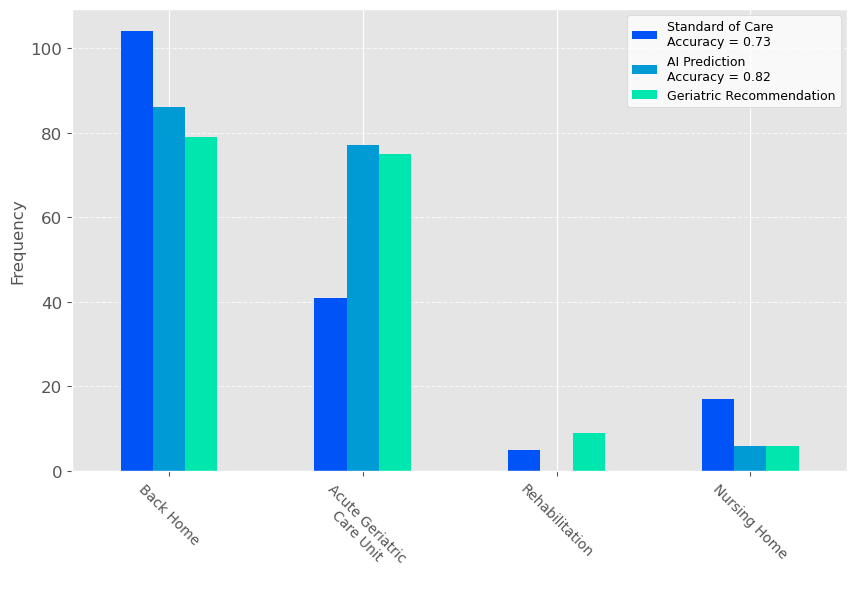

In [10]:
okie = pd.read_csv('./OKIE_data.csv')
soc_accuracy = (okie['coc_gt'] == okie['coc_soc']).sum() / len(okie)

coc_fig_dict = {
    0: 'Back Home',
    1: 'Acute Geriatric \nCare Unit',
    2: 'Rehabilitation',
    3: 'Nursing Home'
}

# Make DataFrame for Figure
coc_fig_df = pd.DataFrame()
coc_fig_df[f'Standard of Care \nAccuracy = {soc_accuracy:.2f}'] = okie['coc_soc'].map(coc_fig_dict).value_counts().reindex(coc_fig_dict.values(), fill_value=0)
coc_fig_df[f'AI Prediction \nAccuracy = {accuracy:.2f}'] = pd.Series(best_y_pred).map(coc_fig_dict).value_counts().reindex(coc_fig_dict.values(), fill_value=0)
coc_fig_df['Geriatric Recommendation'] = okie['coc_gt'].map(coc_fig_dict).value_counts().reindex(coc_fig_dict.values(), fill_value=0)

# Make Figure
plt.style.use('ggplot')
colors = ['#0054f7', '#009ad4', '#00e6af']
ax = coc_fig_df.plot.bar(xlabel='', rot=-45, color=colors, figsize=(10,6))
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles=handles, labels=labels, fontsize=9)
legend.get_frame().set_facecolor('white')

# Save Figure
plt.savefig('./bar_chart.png', bbox_inches='tight', dpi=400)
plt.show();

### Top 85% Predictions
In the SURGE-Ahead application, **15% of patients with lower model confidence** are routed to a **geriatric liaison service** for expert review. \
Specifically, discharge recommendations with a **predicted probability below a predefined threshold** are flagged for geriatrician evaluation.
This ensures that the model only makes high-confidence recommendations for the remaining 85% of cases, balancing **automation** with **expert oversight**.

In [11]:
top_y_true = select_top_rows(best_y_proba, y_true, 15)
top_y_pred = select_top_rows(best_y_proba, best_y_pred, 15)
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
top_y_test = select_top_rows(best_y_proba, y_true_binarized, 15)
top_y_proba = select_top_rows(best_y_proba, best_y_proba, 15)

# Accuracy
accuracy = accuracy_score(top_y_true, top_y_pred)
ci_lower, ci_upper = stratified_bootstrap(top_y_true, top_y_pred, accuracy_score)
print(f"Accuracy: {accuracy:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

# ROC AUC microaverage
roc_auc_micro, ci_lower, ci_upper =  auc_with_ci_stratified(top_y_test.ravel(), top_y_proba.ravel())
print(f"ROC AUC microaverage: {roc_auc_micro:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Accuracy: 0.85
95% Confidence Interval: (0.80, 0.90)
ROC AUC microaverage: 0.95
95% Confidence Interval: (0.93, 0.97)


### Class Performance
Model accuracy was **stratified by care category** using the **One-vs-Rest (OvR)** approach.
This allows evaluation of how well the model predicts each class individually, rather than only overall accuracy.

In [12]:
classes = ['Back Home', 'Acute Geriatric Care Unit', 'Rehabiliation', 'Nursing Home']
ovr_results = {}

for i, cls in enumerate(np.unique(y_true)):
    y_true_bin = (y_true == cls).astype(int)
    y_pred_bin = (best_y_pred == cls).astype(int)

    # Accuracy + CI
    acc = accuracy_score(y_true_bin, y_pred_bin)
    ci_lower, ci_upper = stratified_bootstrap(y_true_bin, y_pred_bin, accuracy_score)

    # ROC AUC + CI in OvR fashion
    auc_val, auc_ci_lower, auc_ci_upper = auc_with_ci_stratified(y_true_binarized[:, i], best_y_proba[:, i])

    ovr_results[classes[i]] = {
        'accuracy': acc,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'auc': auc_val,
        'auc_ci_lower': auc_ci_lower,
        'auc_ci_upper': auc_ci_upper
    }

for cls in classes:
    result = ovr_results[cls]
    print(f"{cls}")
    print(f"Accuracy: {result['accuracy']:.2f}")
    print(f"95% Confidence Interval: ({result['ci_lower']:.2f}, {result['ci_upper']:.2f})")
    print(f"ROC AUC: {result['auc']:.2f}")
    print(f"95% Confidence Interval: ({result['auc_ci_lower']:.2f}, {result['auc_ci_upper']:.2f})")
    print()


Back Home
Accuracy: 0.88
95% Confidence Interval: (0.83, 0.92)
ROC AUC: 0.93
95% Confidence Interval: (0.89, 0.96)

Acute Geriatric Care Unit
Accuracy: 0.83
95% Confidence Interval: (0.78, 0.89)
ROC AUC: 0.89
95% Confidence Interval: (0.84, 0.94)

Rehabiliation
Accuracy: 0.95
95% Confidence Interval: (0.95, 0.95)
ROC AUC: 0.52
95% Confidence Interval: (0.37, 0.69)

Nursing Home
Accuracy: 0.98
95% Confidence Interval: (0.95, 0.99)
ROC AUC: 0.98
95% Confidence Interval: (0.96, 1.00)



### Receiver Operating Characteristic (ROC)
ROC curves are plotted for **each care category** using the **One-vs-Rest (OvR)** method, along with the **micro-average** across all classes. \
The **area under the curve (AUC)** for each class and the micro-average is reported in the figure legend, providing a quantitative measure of the model’s discriminative performance.


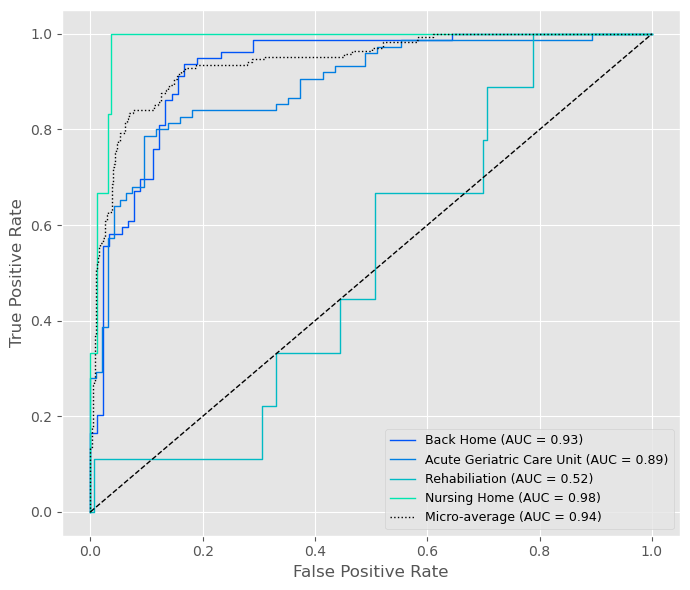

In [13]:
plt.style.use('ggplot')
plt.figure(figsize=(7, 6))

y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
custom_colors = ['#0054F7', '#007EE2', '#00BAC4', '#00E6AF']

for i, color in enumerate(custom_colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], best_y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=1,
             label=f'{classes[i]} (AUC = {roc_auc:.2f})')

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), best_y_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro,
         label=f'Micro-average (AUC = {roc_auc_micro:.2f})',
         color='black', linestyle=':', linewidth=1)

plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ROC.png', bbox_inches='tight', dpi=400)
plt.show()


### Brier Score
The **Brier score** is used to evaluate **probability calibration** of the model. \
It is particularly suitable for **imbalanced classes**, as it measures the accuracy of predicted probabilities rather than just class labels.

In [14]:
brier_score = brier_score_loss(y_true, best_y_proba)
ci_lower, ci_upper = stratified_bootstrap(y_true, best_y_proba, brier_score_loss)
print(f"Brier Score: {brier_score:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Brier Score: 0.33
95% Confidence Interval: (0.30, 0.37)


### Log Loss
Also known as **Cross-Entropy Loss**, log loss is a **calibration metric** that quantifies how well the predicted probabilities match the true class labels. \
Lower values indicate better-calibrated probability predictions.

In [15]:
logloss = log_loss(y_true, best_y_proba)
ci_lower, ci_upper = stratified_bootstrap(y_true, best_y_proba, log_loss)
print(f"Log loss: {logloss:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Log loss: 0.62
95% Confidence Interval: (0.58, 0.68)


### Calibration Curve
Calibration curves are shown for **all four care categories**, including **confidence intervals**.

- Because of the limited data, quartiles were used to group predicted probabilities.
- **Bootstrapping** was applied to estimate confidence intervals.
- Since quartiles can vary between bootstrap iterations, **interpolation** was used to align them for overlaying the results.

This approach allows visual assessment of how well predicted probabilities correspond to actual outcomes, even with a small dataset.

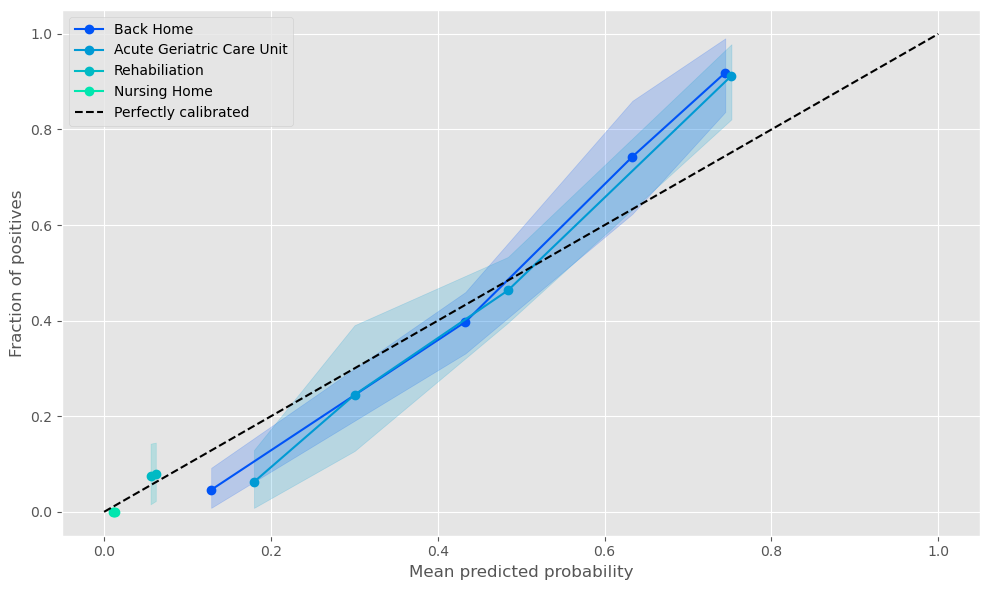

In [16]:
y_true_binarized = label_binarize(y_true, classes=np.arange(len(classes)))

n_bins = 4
n_bootstraps = 1000
plt.figure(figsize=(10, 6))
colors = ['#0054F7', '#009AD4', '#00BAC4', '#00E6AF']

for class_idx, destination in enumerate(classes):
    y_true_binary = y_true_binarized[:, class_idx]
    y_proba_class = best_y_proba[:, class_idx]
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.quantile(y_proba_class, quantiles)
    bin_centers_grid = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    prob_true_boot = []

    # Stratify once
    class_0_idx = np.where(y_true_binary == 0)[0]
    class_1_idx = np.where(y_true_binary == 1)[0]

    for i in range(n_bootstraps):
        sampled_0 = resample(class_0_idx, replace=True, n_samples=len(class_0_idx), random_state=i)
        sampled_1 = resample(class_1_idx, replace=True, n_samples=len(class_1_idx), random_state=i)
        indices = np.concatenate([sampled_0, sampled_1])
        y_sample = y_true_binary[indices]
        prob_sample = y_proba_class[indices]
        prob_true, prob_pred = calibration_curve(y_sample, prob_sample, n_bins=n_bins, strategy='quantile')

        if len(prob_pred) >= 2:
            interp = np.interp(bin_centers_grid, prob_pred, prob_true, left=np.nan, right=np.nan)
            prob_true_boot.append(interp)

    prob_true_boot = np.array(prob_true_boot)
    mask = ~np.isnan(prob_true_boot).all(axis=0)
    mean_true = np.nanmean(prob_true_boot[:, mask], axis=0)
    lower = np.nanpercentile(prob_true_boot[:, mask], 2.5, axis=0)
    upper = np.nanpercentile(prob_true_boot[:, mask], 97.5, axis=0)
    plt.plot(bin_centers_grid[mask], mean_true, label=destination, color=colors[class_idx], marker='o')
    plt.fill_between(bin_centers_grid[mask], lower, upper, alpha=0.2, color=colors[class_idx])

plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('calibration_curves.png', bbox_inches='tight', dpi=400)
plt.show()

## Distribution

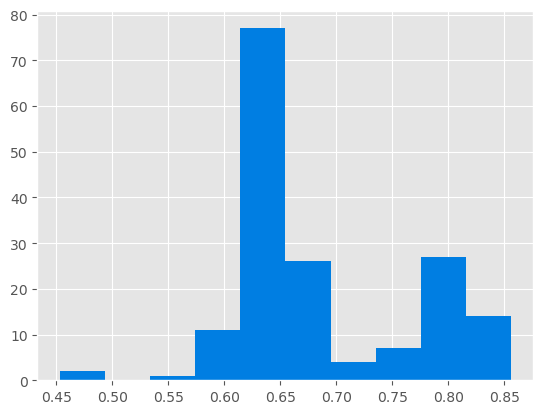

In [17]:
plt.hist(np.max(best_y_proba, axis=1), color='#007EE2')
plt.savefig('histogram.png', bbox_inches='tight', dpi=400)

The **15% of predictions with the lowest confidence** — below a predefined probability threshold—trigger a geriatric liaison service in the SURGE-Ahead project. \
To evaluate whether **higher prediction confidence corresponds to better model performance**, the following curve is plotted.

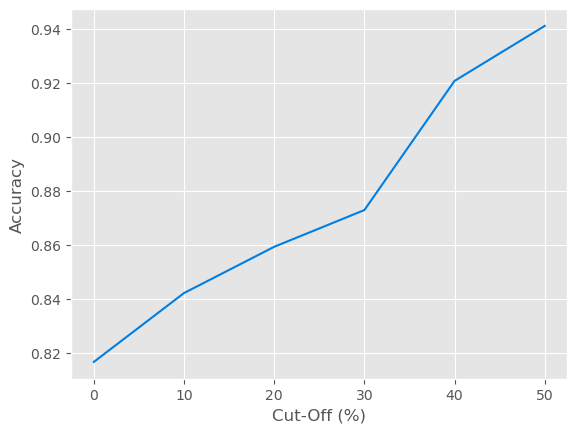

In [18]:
X_chart = []
y_chart = []

for n in np.arange(0, 51, 10):
    accuracy = calculate_top_accuracy(y_true, best_y_pred, best_y_proba, threshold=n)
    X_chart.append(n)
    y_chart.append(accuracy)

plt.xlabel('Cut-Off (%)')
plt.ylabel('Accuracy')

plt.plot(X_chart, y_chart, color='#007EE2')
plt.savefig('cut_offs.png', bbox_inches='tight', dpi=400)

# Train Final Model
The final model is trained using the **best hyperparameters** identified during the grid search. \
It is trained on **all available data** to maximize learning before deployment.

## Preprocess Data

In [19]:
X_SA = X_SA.drop(['Kreuz-Validierung (Fold)'], axis=1) # all data is used
X = pd.concat((X_SA, X_ATZ)) if best_params[0] else X_SA # use trauma register data or not
y = np.concatenate((y_SA, y_ATZ)) if best_params[0] else y_SA # use trauma register data or not

X, X_SA = make_imputation(X, X_SA, data_type_tuple)

## Train Final Model

In [20]:
# AdaBoost yields great performance in imbalanced multi-class problems (Fernandez et al. 2013)
ada = AdaBoostClassifier(
    algorithm='SAMME',
    random_state=42,
    n_estimators=best_params[1],
    learning_rate=best_params[2]
)

# OvO improves performance in imbalanced multi-class problems (Fernandez et al. 2013)
ovo = OneVsOneClassifier(ada)

# Stratified K Fold for calibration
skf = StratifiedKFold(n_splits=best_params[3], shuffle=True, random_state=42)    
cv_splits = [(train_idx, test_idx) for train_idx, test_idx in skf.split(X, y)]

# Sigmoid Calibration due to low sample size
calibrator = CalibratedClassifierCV(
    estimator=ovo,
    method='sigmoid',
    cv=cv_splits,
    n_jobs=-1,
    ensemble=False
)
                    
with warnings.catch_warnings():
    warnings.simplefilter("ignore") # Minority classes raise warnings during calibration
    calibrator.fit(X, y)

# Predictions
y_proba = calibrator.predict_proba(X_SA)
y_pred = np.argmax(y_proba, axis=1)

## Performance
The performance metrics reported here are calculated **on the training data** and should **not be interpreted as true model performance**. \
They are provided primarily to assess whether **substantial overfitting** has occurred.

### Full Accuracy

In [21]:
accuracy = accuracy_score(y_SA, y_pred)
ci_lower, ci_upper = stratified_bootstrap(y_SA, y_pred, accuracy_score)
print(f"Accuracy:: {accuracy:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Accuracy:: 0.85
95% Confidence Interval: (0.80, 0.89)


#### Top 85% Accuracy

In [22]:
accuracy = calculate_top_accuracy(y_SA, y_pred, y_proba)
print(f"Probability Threshold: {np.percentile(np.max(y_proba, axis=1), 15):.2f}")
print(f"Accuracy:: {accuracy:.2f}")

Probability Threshold: 0.64
Accuracy:: 0.92


### Brier Score

In [23]:
brier_score = brier_score_loss(y_SA, y_proba)
ci_lower, ci_upper = stratified_bootstrap(y_SA, y_proba, brier_score_loss)
print(f"Brier Score: {brier_score:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Brier Score: 0.27
95% Confidence Interval: (0.23, 0.30)


### Log Loss

In [24]:
logloss = log_loss(y_SA, y_proba)
ci_lower, ci_upper = stratified_bootstrap(y_SA, y_proba, log_loss)
print(f"Log loss: {logloss:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Log loss: 0.51
95% Confidence Interval: (0.47, 0.56)


## Model Inspection
To understand the model’s behavior, we examine the **features it uses** and their relative contributions. \
This helps assess **which variables drive predictions** and ensures the model’s decisions are interpretable and clinically plausible.

In [25]:
feature_list = []

for j in range(6):
    for i, stump in enumerate(calibrator.calibrated_classifiers_[0].estimator.estimators_[j]):
        feature_list.append(X.columns[stump.tree_.feature[0]])

set(feature_list)

{'ASA (Score, ordinal)',
 'Alter bei OP (Jahre)',
 'Anzahl der Dauermedikamente (n)',
 'Barthel Index am post-OP Tag 3 (Score, ordinal)',
 'Barthel-Index am post-OP Tag 1 (Score, ordinal)',
 'Barthel-Index bei Aufnahme (Score, ordinal)',
 'Barthel-Index vor Aufnahme (Score, ordinal)',
 'Bekommt im Alltag Hilfe (Ja/Nein)',
 'Betreutes Wohnen (Ja/Nein)',
 'CHARMI am post-OP Tag 3 (Score, ordinal)',
 'Clinical Frailty Scale (Score, ordinal)',
 'Demenz (Ja/Nein)',
 'ISAR (Score, ordinal)',
 'Liegedauer auf Intensivstation (Minuten)',
 'Modifizierter Charlson Comorbidity Index (Score, ordinal)',
 'OP Dauer (Minuten)',
 'Pflegegrad (Score, ordinal)',
 'Pflegeheim (Ja/Nein)',
 'Zu Hause mit Hilfe (Ja/Nein)'}

In addition, we focus on the **main estimator**, which differentiates between **“Back Home”** and **“Acute Geriatric Care Unit”** recommendations. \
This distinction is the most **clinically frequent and impactful**, and the main estimator is used to **explain the majority-class decision** to the surgeon.

In [26]:
main_classifier = calibrator.calibrated_classifiers_[0].estimator.estimators_[0]

for i, stump in enumerate(main_classifier.estimators_):
    print('Stump', i+1)
    print(X.columns[stump.tree_.feature[0]])
    print('Threshold: ≤', round(stump.tree_.threshold[0], 2))
    print('Weight', round(main_classifier.estimator_weights_[i], 2))
    print('Left Leave (True)', np.round(stump.tree_.value[1][0], 2))
    print('Right Leave (False)', np.round(stump.tree_.value[2][0], 2))
    print()

Stump 1
Barthel Index am post-OP Tag 3 (Score, ordinal)
Threshold: ≤ 52.5
Weight 1.25
Left Leave (True) [0.27 0.73]
Right Leave (False) [0.88 0.12]

Stump 2
Clinical Frailty Scale (Score, ordinal)
Threshold: ≤ 4.5
Weight 0.9
Left Leave (True) [0.7 0.3]
Right Leave (False) [0.27 0.73]

Stump 3
Barthel-Index am post-OP Tag 1 (Score, ordinal)
Threshold: ≤ 62.5
Weight 0.61
Left Leave (True) [0.41 0.59]
Right Leave (False) [0.95 0.05]

Stump 4
Alter bei OP (Jahre)
Threshold: ≤ 87.5
Weight 0.79
Left Leave (True) [0.67 0.33]
Right Leave (False) [0.2 0.8]

Stump 5
Barthel-Index bei Aufnahme (Score, ordinal)
Threshold: ≤ 67.5
Weight 0.68
Left Leave (True) [0.36 0.64]
Right Leave (False) [0.75 0.25]

Stump 6
Anzahl der Dauermedikamente (n)
Threshold: ≤ 7.5
Weight 0.62
Left Leave (True) [0.72 0.28]
Right Leave (False) [0.4 0.6]

Stump 7
Barthel Index am post-OP Tag 3 (Score, ordinal)
Threshold: ≤ 42.5
Weight 0.62
Left Leave (True) [0.19 0.81]
Right Leave (False) [0.62 0.38]

Stump 8
Barthel-Index

## Save Model

In [27]:
dump(calibrator, 'coc_predictor.joblib');